# Model 6 — Feature Association Rule Mining (Apriori)

## Research Question
What combinations of car features tend to appear together — and do certain combinations reliably predict very expensive, very cheap, or heavily damaged cars?

## Introduction

This notebook uses the **Apriori algorithm** (`mlxtend`) to discover
association rules between binary car features.

**Parameters used in this notebook:**
- `min_support = 0.02` — lowered from the default 0.05 to allow rare
  target columns (`cok_pahali`, `cok_ucuz`) to appear in rules, as they
  represent exactly the top and bottom 5% of prices by construction.
- `metric = 'lift', min_threshold = 1.5` — lift was used as the primary
  filter instead of confidence, which is more appropriate for rare targets
  where absolute confidence is naturally low.
- `Kasa Tipi_SUV` was excluded from the transaction matrix (95% support)
  as it appeared in nearly every itemset without carrying discriminative
  information.

## Data Import

Run this cell as-is. It loads all required libraries and the unscaled dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

## Feature Engineering

Run this cell as-is. It creates seven custom binary columns that will be used as special items in the transaction matrix:

| Column | Meaning |
|---|---|
| `cok_pahali` | Price ≥ 95th percentile |
| `cok_ucuz` | Price ≤ 5th percentile |
| `yuksek_km` | Mileage > 150,000 km |
| `dusuk_km` | Mileage < 30,000 km |
| `yeni_araba` | Year ≥ 2022 |
| `eski_araba` | Year ≤ 2015 |
| `agir_hasar` | Damage score ≥ 75th percentile |

In [4]:
# Create custom binary columns for association mining
df['cok_pahali'] = (df['Fiyat'] >= df['Fiyat'].quantile(0.95)).astype(int)
df['cok_ucuz']   = (df['Fiyat'] <= df['Fiyat'].quantile(0.05)).astype(int)
df['yuksek_km']  = (df['Kilometre'] > 150000).astype(int)
df['dusuk_km']   = (df['Kilometre'] < 30000).astype(int)
df['yeni_araba'] = (df['Yıl'] >= 2022).astype(int)
df['eski_araba'] = (df['Yıl'] <= 2015).astype(int)
df['agir_hasar'] = (df['paint_damage_score'] >= df['paint_damage_score'].quantile(0.75)).astype(int)

print("Engineered columns created:")
for col in ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km', 'yeni_araba', 'eski_araba', 'agir_hasar']:
    print(f"  {col}: {df[col].sum()} cars ({df[col].mean()*100:.1f}%)")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Engineered columns created:
  cok_pahali: 130 cars (5.0%)
  cok_ucuz: 130 cars (5.0%)
  yuksek_km: 837 cars (32.3%)
  dusuk_km: 402 cars (15.5%)
  yeni_araba: 773 cars (29.9%)
  eski_araba: 823 cars (31.8%)
  agir_hasar: 828 cars (32.0%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Transaction Dataset Construction

Run this cell as-is. It combines the engineered binary columns with all existing one-hot encoded columns (body type, fuel type, drivetrain, seller type, brand flags) into a boolean transaction matrix suitable for Apriori.

In [5]:
# Combine engineered columns with existing binary one-hot columns
engineered_cols = ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km',
                   'yeni_araba', 'eski_araba', 'agir_hasar']

# Find all existing binary one-hot columns
onehot_patterns = ['Kasa Tipi_', 'Yakıt Tipi_', 'Çekiş_', 'Kimden_', 'is_Nissan']
onehot_cols = [c for c in df.columns for p in onehot_patterns if c.startswith(p)]

transaction_cols = engineered_cols + onehot_cols
transaction_cols = [c for c in transaction_cols if c in df.columns]

transactions = df[transaction_cols].fillna(0).astype(bool)
print(f"Transaction matrix: {transactions.shape[0]} rows × {transactions.shape[1]} items")
print(f"Total item columns: {transactions.columns.tolist()}")

Transaction matrix: 2589 rows × 23 items
Total item columns: ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km', 'yeni_araba', 'eski_araba', 'agir_hasar', 'is_Nissan', 'Kimden_Sahibinden', 'Kimden_Yetkili Bayiden', 'Yakıt Tipi_Dizel', 'Yakıt Tipi_Elektrik', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_LPG & Benzin', 'Kasa Tipi_Coupe', 'Kasa Tipi_Crossover', 'Kasa Tipi_Hard top', 'Kasa Tipi_Panelvan', 'Kasa Tipi_Pick-Up', 'Kasa Tipi_SUV', 'Çekiş_AWD (Elektronik)', 'Çekiş_Arkadan İtiş', 'Çekiş_Önden Çekiş']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Frequent Itemset Mining

The **Apriori** algorithm to find frequent itemsets.

- Lower `min_support` → more itemsets found, but may include noisy/spurious ones
- Higher `min_support` → fewer, more reliable itemsets
- Adjust `max_len` to control the maximum number of items per itemset

In [6]:
# Lower min_support to 0.02 so that combinations involving rare targets
# (cok_pahali, cok_ucuz at ~5%) can survive the pruning step.
# cok_pahali ∩ yeni_araba could realistically be ~2-3% of all cars.

# Also exclude Kasa Tipi_SUV: present in 95% of cars, it adds noise
# to every itemset without carrying useful discriminative information.
non_informative = ['Kasa Tipi_SUV']
filtered_transactions = transactions.drop(columns=non_informative, errors='ignore')

frequent_itemsets = apriori(
    filtered_transactions,
    min_support=0.02,    # low enough to capture rare target combinations
    use_colnames=True,
    max_len=4
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print(f"\nBreakdown by itemset size:")
print(frequent_itemsets['length'].value_counts().sort_index())

# Check if target columns now appear in the itemsets
target_cols = ['cok_pahali', 'cok_ucuz', 'agir_hasar']
print(f"\nTarget columns appearing in itemsets:")
for t in target_cols:
    count = frequent_itemsets['itemsets'].apply(lambda x: t in x).sum()
    print(f"  {t}: {count} itemsets")

frequent_itemsets.sort_values('support', ascending=False).head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total frequent itemsets found: 209

Breakdown by itemset size:
length
1    16
2    56
3    81
4    56
Name: count, dtype: int64

Target columns appearing in itemsets:
  cok_pahali: 8 itemsets
  cok_ucuz: 28 itemsets
  agir_hasar: 57 itemsets


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets,length
15,0.791039,(Çekiş_Önden Çekiş),1
7,0.517574,(is_Nissan),1
9,0.491696,(Yakıt Tipi_Dizel),1
62,0.443028,"(is_Nissan, Çekiş_Önden Çekiş)",2
8,0.368482,(Kimden_Sahibinden),1
69,0.354577,"(Çekiş_Önden Çekiş, Yakıt Tipi_Dizel)",2
2,0.323291,(yuksek_km),1
6,0.319815,(agir_hasar),1
5,0.317883,(eski_araba),1
58,0.305137,"(is_Nissan, Yakıt Tipi_Dizel)",2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Association Rules Generation

Generate of association rules from the frequent itemsets.

- Higher `min_threshold` for confidence → fewer but more reliable rules
- Sort by `lift` to find rules where the co-occurrence is much higher than chance

In [7]:
# min_threshold lowered to 0.4 to allow more rules involving rare targets
# We sort by lift: values > 2.0 indicate a genuinely strong association

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.4
)

rules = rules.sort_values('lift', ascending=False)

rules['rule_str'] = rules.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

print(f"Total rules generated: {len(rules)}")
print(f"Rules with lift > 2.0 (strong): {len(rules[rules['lift'] > 2.0])}")
print(f"\nTop 10 rules by lift:")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total rules generated: 618
Rules with lift > 2.0 (strong): 259

Top 10 rules by lift:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
526,"(Yakıt Tipi_Hibrit, Çekiş_Önden Çekiş)","(is_Nissan, yeni_araba)",0.025879,0.971014,10.697687
529,(Yakıt Tipi_Hibrit),"(is_Nissan, Çekiş_Önden Çekiş, yeni_araba)",0.025879,0.788235,10.684509
190,(Yakıt Tipi_Hibrit),"(is_Nissan, yeni_araba)",0.030900,0.941176,10.368961
343,(cok_ucuz),"(Yakıt Tipi_Dizel, eski_araba, Kimden_Sahibinden)",0.020085,0.400000,5.850847
308,(cok_ucuz),"(Yakıt Tipi_Dizel, eski_araba, yuksek_km)",0.043646,0.869231,5.654368
60,(cok_pahali),"(dusuk_km, yeni_araba)",0.038625,0.769231,5.254719
63,(cok_pahali),"(is_Nissan, yeni_araba)",0.023175,0.461538,5.084779
59,"(cok_pahali, yeni_araba)",(dusuk_km),0.038625,0.775194,4.992479
0,(cok_pahali),(dusuk_km),0.038625,0.769231,4.954076
328,"(agir_hasar, cok_ucuz)","(Yakıt Tipi_Dizel, eski_araba)",0.022402,0.906250,4.939539


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##Coloumns to display

For the next parts of the notebook the focus coloumns to use

In [8]:
# Columns to display in all evaluation tables
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Why Lift Instead of Confidence?

`cok_pahali` and `cok_ucuz` represent by construction exactly the top
and bottom 5% of prices in the dataset. This creates a mathematical
constraint: any rule predicting these targets will have a naturally low
confidence, even when the association is genuinely strong.

For example, the rule `{yeni_araba, dusuk_km} → {cok_pahali}` has a
confidence of 0.26 — meaning 26% of new low-mileage cars are very
expensive. Filtered by confidence alone, this rule would be discarded
as too weak. Yet its lift is 5.25, meaning this combination is 5x more
likely to predict an expensive car than random chance. That is a strong
and meaningful association.

Lift normalizes by the rarity of the target:

    lift = confidence / P(target)
         = 0.26 / 0.05
         = 5.2

This is why lift was used as the primary filtering metric for
target-specific rules (`rules_target`), while confidence was kept as
the main metric only for general structural rules (`rules`).
A lift threshold of 1.5 was applied — meaning only

In [9]:
# Use lift as the primary filter metric instead of confidence.
# This is more appropriate for rare targets (cok_pahali, cok_ucuz at ~5%):
# a rule can have low confidence but very high lift — meaning the association
# is much stronger than chance even if the absolute probability is small.

rules_target = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.5   # only keep rules that are 1.5x better than random chance
)

rules_target = rules_target.sort_values('lift', ascending=False)

rules_target['rule_str'] = rules_target.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

print(f"Total rules: {len(rules_target)}")

for target in ['cok_pahali', 'cok_ucuz', 'agir_hasar']:
    count = rules_target['consequents'].apply(lambda x: target in x).sum()
    print(f"  Rules predicting {target}: {count}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total rules: 818
  Rules predicting cok_pahali: 9
  Rules predicting cok_ucuz: 92
  Rules predicting agir_hasar: 142


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Evaluation

### Top Rules Predicting Very Expensive Cars (`cok_pahali`)

Filters rules whose consequent is `cok_pahali` and ranks them by confidence.


In [10]:

pahali_rules = rules_target[rules_target['consequents'].apply(lambda x: 'cok_pahali' in x)]
pahali_rules_sorted = pahali_rules.sort_values('confidence', ascending=False).head(10)

print("=== Top 10 Rules Predicting VERY EXPENSIVE Cars ===\n")
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
if len(pahali_rules_sorted) > 0:
    styled = pahali_rules_sorted[display_cols].reset_index(drop=True)
    styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
    styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
    print(styled.to_string(index=False))
    strong = pahali_rules_sorted[pahali_rules_sorted['lift'] > 2.0]
    if len(strong) > 0:
        print(f"\n⭐ {len(strong)} rule(s) with lift > 2.0 (STRONG associations):")
        for _, r in strong.iterrows():
            print(f"   {set(r['antecedents'])} → {set(r['consequents'])} | lift={r['lift']:.2f}")
else:
    print("No rules found. Try lowering min_support or min_threshold.")

=== Top 10 Rules Predicting VERY EXPENSIVE Cars ===

                  antecedents                   consequents  support  confidence     lift
         dusuk_km, yeni_araba                    cok_pahali 0.038625    0.263852 5.254719
        is_Nissan, yeni_araba                    cok_pahali 0.023175    0.255319 5.084779
                     dusuk_km        cok_pahali, yeni_araba 0.038625    0.248756 4.992479
                     dusuk_km                    cok_pahali 0.038625    0.248756 4.954076
                   yeni_araba                    cok_pahali 0.049826    0.166882 3.323525
                   yeni_araba          cok_pahali, dusuk_km 0.038625    0.129366 3.349288
Çekiş_Önden Çekiş, yeni_araba                    cok_pahali 0.020471    0.087603 1.744654
                   yeni_araba         cok_pahali, is_Nissan 0.023175    0.077620 3.294382
                   yeni_araba cok_pahali, Çekiş_Önden Çekiş 0.020471    0.068564 3.287265

⭐ 8 rule(s) with lift > 2.0 (STRONG associatio

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Top Rules Predicting Very Cheap Cars (`cok_ucuz`)

Filters rules whose consequent is `cok_ucuz` and ranks them by confidence.


In [11]:

ucuz_rules = rules_target[rules_target['consequents'].apply(lambda x: 'cok_ucuz' in x)]
ucuz_rules_sorted = ucuz_rules.sort_values('confidence', ascending=False).head(10)

print("=== Top 10 Rules Predicting VERY CHEAP Cars ===\n")
if len(ucuz_rules_sorted) > 0:
    styled = ucuz_rules_sorted[display_cols].reset_index(drop=True).copy()
    styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
    styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
    print(styled.to_string(index=False))
else:
    print("No rules found. Try lowering min_support or min_threshold.")

=== Top 10 Rules Predicting VERY CHEAP Cars ===

                                    antecedents                consequents  support  confidence     lift
Yakıt Tipi_Dizel, eski_araba, Kimden_Sahibinden                   cok_ucuz 0.020085    0.293785 5.850847
        Yakıt Tipi_Dizel, eski_araba, yuksek_km                   cok_ucuz 0.043646    0.283920 5.654368
                   Yakıt Tipi_Dizel, eski_araba                   cok_ucuz 0.044419    0.242105 4.821619
                   Yakıt Tipi_Dizel, eski_araba        yuksek_km, cok_ucuz 0.043646    0.237895 4.849681
       Yakıt Tipi_Dizel, eski_araba, agir_hasar                   cok_ucuz 0.022402    0.232000 4.620369
       eski_araba, yuksek_km, Kimden_Sahibinden                   cok_ucuz 0.023175    0.224719 4.475367
                          eski_araba, yuksek_km                   cok_ucuz 0.049054    0.223592 4.452912
               is_Nissan, eski_araba, yuksek_km                   cok_ucuz 0.031672    0.206030 4.103170
      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Top Rules Predicting Heavily Damaged Cars (`agir_hasar`)

Filters rules whose consequent is `agir_hasar` and ranks them by confidence.


In [12]:

hasar_rules = rules_target[rules_target['consequents'].apply(lambda x: 'agir_hasar' in x)]
hasar_rules_sorted = hasar_rules.sort_values('confidence', ascending=False).head(10)

print("=== Top 10 Rules Predicting HEAVILY DAMAGED Cars ===\n")
if len(hasar_rules_sorted) > 0:
    styled = hasar_rules_sorted[display_cols].reset_index(drop=True).copy()
    styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
    styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
    print(styled.to_string(index=False))
else:
    print("No rules found. Try lowering min_support or min_threshold.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Top 10 Rules Predicting HEAVILY DAMAGED Cars ===

                                           antecedents consequents  support  confidence     lift
                      is_Nissan, eski_araba, yuksek_km  agir_hasar 0.086906    0.565327 1.767670
               Yakıt Tipi_Dizel, eski_araba, yuksek_km  agir_hasar 0.085361    0.555276 1.736245
              Çekiş_Önden Çekiş, eski_araba, yuksek_km  agir_hasar 0.091155    0.553991 1.732224
               is_Nissan, Çekiş_Önden Çekiş, yuksek_km  agir_hasar 0.100811    0.552966 1.729021
               is_Nissan, yuksek_km, Kimden_Sahibinden  agir_hasar 0.036694    0.542857 1.697412
Yakıt Tipi_LPG & Benzin, eski_araba, Çekiş_Önden Çekiş  agir_hasar 0.023175    0.540541 1.690168
                                 eski_araba, yuksek_km  agir_hasar 0.118579    0.540493 1.690020
                                  is_Nissan, yuksek_km  agir_hasar 0.120896    0.536878 1.678717
                is_Nissan, Yakıt Tipi_Dizel, yuksek_km  agir_hasar 0.1027

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Top 10 Rules by Lift (Strongest Natural Associations)

Lift > 1 means the items co-occur more than expected by chance. Lift > 2 is considered a strong association.

In [14]:
# Exclude all rules involving Yakıt Tipi_Hibrit — these are brand tautologies
# (almost all hybrids in the dataset are Nissan) and carry no useful
# predictive information about price or damage.
def contains_hibrit(row):
    all_items = set(row['antecedents']) | set(row['consequents'])
    return 'Yakıt Tipi_Hibrit' in all_items

top10_lift = rules_target[~rules_target.apply(contains_hibrit, axis=1)] \
                .sort_values('lift', ascending=False) \
                .head(10) \
                .reset_index(drop=True)

print("=== Top 10 Rules by Lift (Strongest Natural Associations) ===\n")
styled = top10_lift[display_cols].reset_index(drop=True).copy()
styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
print(styled.to_string(index=False))

strong_all = rules_target[rules_target['lift'] > 2.0]
print(f"\n⭐ Total rules with lift > 2.0: {len(strong_all)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Top 10 Rules by Lift (Strongest Natural Associations) ===

                                    antecedents                                     consequents  support  confidence     lift
Yakıt Tipi_Dizel, eski_araba, Kimden_Sahibinden                                        cok_ucuz 0.020085    0.293785 5.850847
                                       cok_ucuz Yakıt Tipi_Dizel, eski_araba, Kimden_Sahibinden 0.020085    0.400000 5.850847
                                       cok_ucuz         Yakıt Tipi_Dizel, eski_araba, yuksek_km 0.043646    0.869231 5.654368
        Yakıt Tipi_Dizel, eski_araba, yuksek_km                                        cok_ucuz 0.043646    0.283920 5.654368
                           dusuk_km, yeni_araba                                      cok_pahali 0.038625    0.263852 5.254719
                                     cok_pahali                            dusuk_km, yeni_araba 0.038625    0.769231 5.254719
                          is_Nissan, yeni_araba        

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Support vs Confidence Scatter Plot

Each point is one association rule. Point size encodes lift. Color indicates the type of consequent:
- 🔴 Red = `cok_pahali` (very expensive)
- 🔵 Blue = `cok_ucuz` (very cheap)
- 🟣 Purple = `agir_hasar` (heavy damage)
- ⚫ Grey = other consequents


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

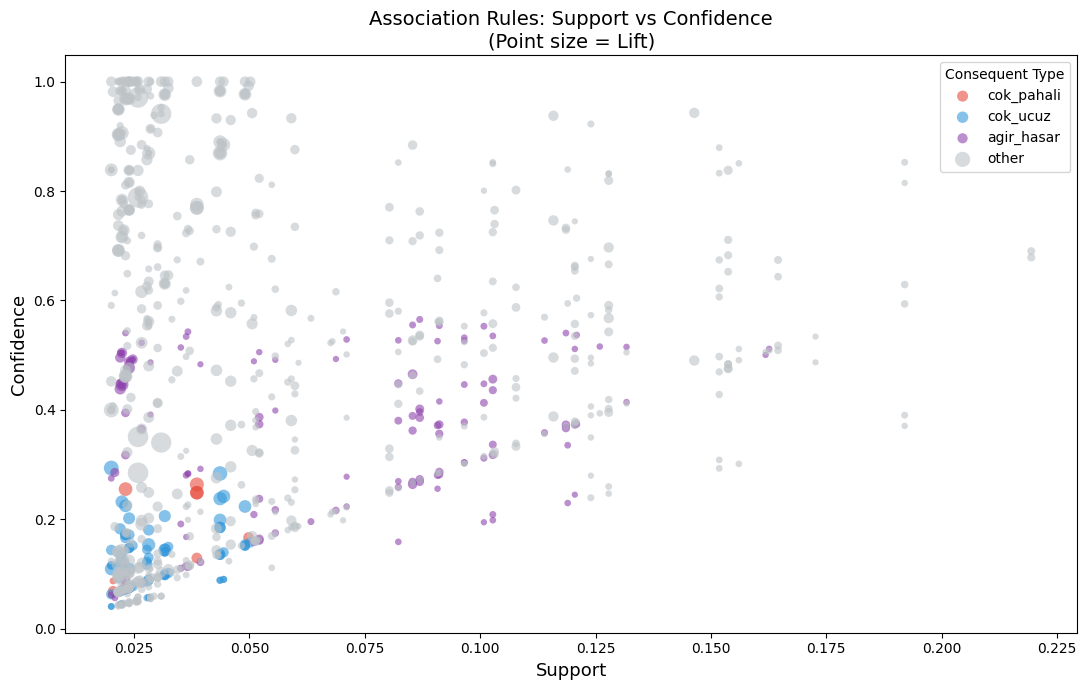

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:

target_consequents = ['cok_pahali', 'cok_ucuz', 'agir_hasar']
color_map = {'cok_pahali': '#e74c3c', 'cok_ucuz': '#3498db', 'agir_hasar': '#8e44ad', 'other': '#bdc3c7'}

def get_color(row):
    for t in target_consequents:
        if t in row['consequents']:
            return color_map[t]
    return color_map['other']

plot_rules = rules_target.copy()
plot_rules['color'] = plot_rules.apply(get_color, axis=1)
plot_rules['lift_scaled'] = (plot_rules['lift'] - plot_rules['lift'].min()) / (plot_rules['lift'].max() - plot_rules['lift'].min() + 1e-9) * 200 + 20

fig, ax = plt.subplots(figsize=(11, 7))
for label, color in color_map.items():
    mask = plot_rules['color'] == color
    if mask.sum() > 0:
        ax.scatter(plot_rules.loc[mask, 'support'],
                   plot_rules.loc[mask, 'confidence'],
                   s=plot_rules.loc[mask, 'lift_scaled'],
                   c=color, alpha=0.6, label=label, edgecolors='none')

ax.set_xlabel('Support', fontsize=13)
ax.set_ylabel('Confidence', fontsize=13)
ax.set_title('Association Rules: Support vs Confidence\n(Point size = Lift)', fontsize=14)
ax.legend(title='Consequent Type')
plt.tight_layout()
plt.show()

### Top 10 Rules by Lift — Bar Chart

Horizontal bar chart of the 10 rules with the highest lift. Rules with lift > 2.0 are highlighted in red.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

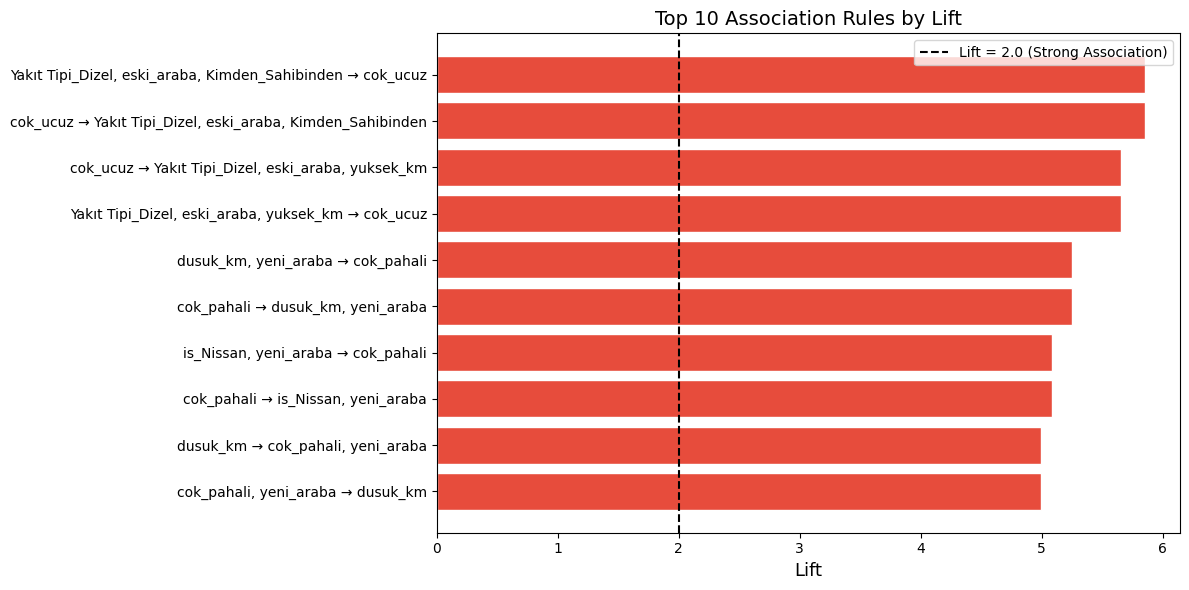

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
# Exclude Yakıt Tipi_Hibrit tautology rules before plotting
def contains_hibrit(row):
    all_items = set(row['antecedents']) | set(row['consequents'])
    return 'Yakıt Tipi_Hibrit' in all_items

top10_lift = rules_target[~rules_target.apply(contains_hibrit, axis=1)] \
                .nlargest(10, 'lift') \
                .reset_index(drop=True)

top10_lift['rule_label'] = top10_lift.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}", axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if r['lift'] > 2 else '#3498db' for _, r in top10_lift.iterrows()]
ax.barh(top10_lift['rule_label'], top10_lift['lift'], color=colors, edgecolor='white')
ax.axvline(2.0, color='black', linestyle='--', linewidth=1.5, label='Lift = 2.0 (Strong Association)')
ax.set_xlabel('Lift', fontsize=13)
ax.set_title('Top 10 Association Rules by Lift', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusion

**Price is highly predictable.**
The model found strong rules for both price extremes (lift > 5.0).
Very expensive cars are consistently associated with low mileage and recent
year (`yeni_araba + dusuk_km → cok_pahali`, lift=5.25), while very cheap cars
are strongly linked to old age, high mileage, and diesel fuel
(`eski_araba + yuksek_km + Yakıt Tipi_Dizel → cok_ucuz`, lift=5.65).
These two profiles are near-perfect opposites, reflecting a well-structured
market where freshness drives value and wear drives depreciation.

**Damage is largely unpredictable.**
No rule predicting `agir_hasar` exceeded a lift of 1.77, well below the
threshold of 2.0 considered a strong association. High mileage (`yuksek_km`)
was the only consistent predictor, suggesting that paint and body damage
depends more on individual vehicle history than on observable structural
features.

**Modeling note.**
Two parameter adjustments were necessary to surface meaningful rules.
First, `min_support` was lowered from 0.05 to 0.02, as target columns
(`cok_pahali`, `cok_ucuz`) represent exactly the top and bottom 5% of prices
by construction — combinations involving them fall below any 5% threshold.
Second, rules were filtered by lift rather than confidence, which is more
appropriate for rare targets where absolute confidence is naturally low.

### Limitations

The dataset is heavily dominated by a single body type (SUV, 95% of cars)
and a single brand (Nissan, ~52%), which limits the generalizability of
brand-specific rules. Future work could apply Apriori to a more balanced
dataset or combine these association rules with a supervised model to
move from description to prediction.